# Byte Pair Encoding (BPE) 논문 분석 & 구현

> **논문**: Sennrich, R., Haddow, B., & Birch, A. (2016).  
> *"Neural Machine Translation of Rare Words with Subword Units"*  
> ACL 2016 — 인용 수 7000+

---

## 논문 핵심 요약

### 문제 인식
```
NMT(신경망 기계 번역)의 고정 어휘(Fixed Vocabulary) 한계:
  ① 희귀 단어(Rare Words): 어휘 밖 → <UNK> 처리 → 번역 오류
  ② 미등록 단어(OOV): 학습 안된 단어 → 완전히 처리 불가
  ③ 형태론적 풍부성: 독일어/한국어 등 → 어절 변화 무한
  
  예: 'Bundesgesundheitsminister' (독일어: 연방보건장관)
     → 단어 단위: OOV (학습 불가)
     → BPE: 'Bundes' + 'gesund' + 'heits' + 'minister' (분해 가능)
```

### 해결책: BPE 적용
```
원래 BPE: 데이터 압축 알고리즘 (Gage, 1994)
  → NLP에 적용: 어휘 생성 알고리즘으로 변용

핵심 아이디어:
  1. 모든 단어를 문자(character) 단위로 분리
  2. 가장 빈번한 인접 문자 쌍을 합쳐 새 기호 생성
  3. 원하는 어휘 크기에 도달할 때까지 반복
```

### 논문의 주요 발견
- BPE 어휘 크기 **32,000**에서 최적 성능 (영←→독, 영←→러)
- 단어 단위 대비 **+1~2 BLEU** 향상
- **Joint BPE** (원문+번역문 공통 학습)이 독립 학습보다 효과적
- 희귀 단어 번역 품질 **크게 향상**

In [1]:
# ── 한글 폰트 설정 ──────────────────────────────────────────
!apt-get install -y fonts-nanum > /dev/null 2>&1
!fc-cache -fv > /dev/null 2>&1
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm
font_path = '/usr/share/fonts/truetype/nanum/NanumGothic.ttf'
fm.fontManager.addfont(font_path)
plt.rcParams['font.family'] = 'NanumGothic'
plt.rcParams['axes.unicode_minus'] = False

import re, math, json
import numpy as np
import pandas as pd
import seaborn as sns
from collections import Counter, defaultdict
import warnings
warnings.filterwarnings('ignore')

print('✅ 설정 완료')

✅ 설정 완료


## 1️⃣ 논문 Algorithm 1 — BPE 정확한 재현

```
Algorithm 1 (논문 원문):
  Input : 문자열 sequence, 병합 횟수 k
  Output: 병합 규칙 집합
  
  1. word vocabulary 초기화 (단어 + 빈도)
  2. 각 단어를 문자 + </w> 로 분리
  3. repeat k times:
     a. 인접 기호 쌍의 빈도 계산
     b. 가장 빈번한 쌍 (A, B) 선택
     c. 모든 등장에서 A B → AB 병합
     d. 병합 규칙 저장
  4. return 병합 규칙 집합
```

In [2]:
class BPE:
    """
    논문 Algorithm 1의 완전한 구현
    Sennrich et al. (2016) ACL

    원본 GitHub: https://github.com/rsennrich/subword-nmt
    """

    WORD_END = '</w>'  # 논문 표기: 단어 끝 마커

    def __init__(self):
        self.merges      = []       # 병합 규칙: [(pair, merged), ...]
        self.vocab       = {}       # 학습된 어휘
        self.bpe_codes   = {}       # 병합 규칙 딕셔너리 (빠른 조회)
        self.word_splits = {}       # 현재 단어 분할 상태

    # ── Step 1: 단어 빈도 수집 ──────────────────────────────
    def _get_vocab(self, sentences):
        """
        논문: "We initialize the symbol vocabulary with the character vocabulary"
        단어 끝에 </w> 추가 → 단어 경계 보존
        """
        vocab = Counter()
        for sent in sentences:
            for word in sent.strip().split():
                vocab[word] += 1
        # 각 단어를 문자 + </w> 로 분리
        return {' '.join(list(word) + [self.WORD_END]): freq
                for word, freq in vocab.items()}

    # ── Step 2: 인접 쌍 빈도 계산 ───────────────────────────
    def _get_stats(self, vocab):
        """
        논문: "count frequency of all symbol pairs"
        """
        pairs = Counter()
        for word, freq in vocab.items():
            symbols = word.split()
            for i in range(len(symbols) - 1):
                pairs[(symbols[i], symbols[i+1])] += freq
        return pairs

    # ── Step 3: 최빈 쌍 병합 ────────────────────────────────
    def _merge_vocab(self, pair, vocab):
        """
        논문: "merge all occurrences of the most frequent pair"
        정규식으로 쌍을 찾아 병합 (공백 제거)
        """
        bigram  = re.escape(' '.join(pair))
        pattern = re.compile(r'(?<!\S)' + bigram + r'(?!\S)')
        merged  = ''.join(pair)  # 공백 없이 합치기
        new_vocab = {}
        for word, freq in vocab.items():
            new_word = pattern.sub(merged, word)
            new_vocab[new_word] = freq
        return new_vocab

    # ── 메인 학습 함수 ───────────────────────────────────────
    def fit(self, sentences, num_merges=100, verbose=True):
        """
        논문 Algorithm 1 실행

        num_merges: 병합 횟수 k
                    논문: "We chose between 10,000 and 80,000 for NMT"
        """
        vocab = self._get_vocab(sentences)
        self.initial_vocab = dict(vocab)

        if verbose:
            print(f'초기 어휘 크기: {len(vocab)} 단어 유형')
            init_symbols = set(s for w in vocab for s in w.split())
            print(f'초기 기호 수:   {len(init_symbols)}개')
            print(f'병합 횟수:      {num_merges}회\n')
            print(f'{"#":>4} | {"병합 쌍":>20} | {"결과 기호":>15} | 빈도')
            print('-' * 55)

        for i in range(num_merges):
            pairs = self._get_stats(vocab)
            if not pairs:
                break

            best_pair = max(pairs, key=pairs.get)
            best_freq = pairs[best_pair]

            vocab = self._merge_vocab(best_pair, vocab)
            merged_symbol = ''.join(best_pair)
            self.merges.append((best_pair, merged_symbol, best_freq))
            self.bpe_codes[best_pair] = i  # 병합 우선순위 저장

            if verbose and (i < 15 or i % 20 == 0):
                print(f'{i+1:>4} | {"+".join(f"{p!r}" for p in best_pair):>20} | {merged_symbol!r:>15} | {best_freq}')

        self.vocab = vocab
        self.word_splits = vocab

        final_symbols = set(s for w in vocab for s in w.split())
        print(f'\n최종 기호 수: {len(final_symbols)}개  (초기 문자 + {num_merges}회 병합)')
        return self

    # ── 인코딩 (테스트 시 병합 규칙 적용) ────────────────────
    def encode(self, word):
        """
        학습된 병합 규칙을 순서대로 적용
        논문: "apply the merge operations in the order they were learned"
        """
        symbols = list(word) + [self.WORD_END]

        while len(symbols) > 1:
            # 가장 높은 우선순위(낮은 인덱스)의 쌍 찾기
            pairs = [(symbols[i], symbols[i+1]) for i in range(len(symbols)-1)]
            best  = min(pairs,
                        key=lambda p: self.bpe_codes.get(p, float('inf')))

            if best not in self.bpe_codes:
                break  # 더 이상 병합할 쌍 없음

            # 병합 실행
            new_symbols = []
            i = 0
            while i < len(symbols):
                if i < len(symbols)-1 and (symbols[i], symbols[i+1]) == best:
                    new_symbols.append(symbols[i] + symbols[i+1])
                    i += 2
                else:
                    new_symbols.append(symbols[i])
                    i += 1
            symbols = new_symbols

        return symbols

    def tokenize(self, sentence):
        tokens = []
        for word in sentence.strip().split():
            tokens.extend(self.encode(word))
        return tokens


# 논문 예제로 테스트
paper_example = [
    'low low low low low lower lower newest newest newest newest newest newest newest '
    'newest wider wider wider newer newer newer newer newer newer'
]

bpe = BPE()
bpe.fit(paper_example, num_merges=15, verbose=True)

초기 어휘 크기: 5 단어 유형
초기 기호 수:   11개
병합 횟수:      15회

   # |                 병합 쌍 |           결과 기호 | 빈도
-------------------------------------------------------
   1 |              'w'+'e' |            'we' | 16
   2 |              'n'+'e' |            'ne' | 14
   3 |            'ne'+'we' |          'newe' | 14
   4 |           'r'+'</w>' |         'r</w>' | 11
   5 |           'newe'+'s' |         'newes' | 8
   6 |          'newes'+'t' |        'newest' | 8
   7 |      'newest'+'</w>' |    'newest</w>' | 8
   8 |              'l'+'o' |            'lo' | 7
   9 |       'newe'+'r</w>' |     'newer</w>' | 6
  10 |             'lo'+'w' |           'low' | 5
  11 |         'low'+'</w>' |       'low</w>' | 5
  12 |              'w'+'i' |            'wi' | 3
  13 |             'wi'+'d' |           'wid' | 3
  14 |            'wid'+'e' |          'wide' | 3
  15 |       'wide'+'r</w>' |     'wider</w>' | 3

최종 기호 수: 7개  (초기 문자 + 15회 병합)


## 2️⃣ BPE 병합 과정 단계별 시각화

In [3]:
def trace_bpe_steps(sentences, num_merges=10):
    """BPE 병합 과정을 매 스텝 기록"""
    def get_vocab(sents):
        vocab = Counter()
        for s in sents:
            for w in s.strip().split():
                vocab[w] += 1
        return {' '.join(list(w) + ['</w>']): f for w, f in vocab.items()}

    def get_stats(vocab):
        pairs = Counter()
        for word, freq in vocab.items():
            syms = word.split()
            for i in range(len(syms)-1):
                pairs[(syms[i], syms[i+1])] += freq
        return pairs

    def merge(pair, vocab):
        pat = re.compile(r'(?<!\S)' + re.escape(' '.join(pair)) + r'(?!\S)')
        return {pat.sub(''.join(pair), w): f for w, f in vocab.items()}

    vocab = get_vocab(sentences)
    steps = []
    steps.append({'step': 0, 'vocab': dict(vocab), 'merge': None, 'freq': None})

    for step in range(num_merges):
        pairs = get_stats(vocab)
        if not pairs: break
        best = max(pairs, key=pairs.get)
        vocab = merge(best, vocab)
        steps.append({
            'step':  step+1,
            'vocab': dict(vocab),
            'merge': best,
            'freq':  pairs[best]
        })

    return steps


steps = trace_bpe_steps(paper_example, num_merges=8)

print('[BPE 병합 과정 단계별 추적]\n')
for s in steps:
    if s['step'] == 0:
        print(f'초기 상태:')
    else:
        print(f'\nStep {s["step"]}: {s["merge"][0]!r} + {s["merge"][1]!r} → {"\"" + s["merge"][0]+s["merge"][1] + "\""} (빈도={s["freq"]})')
    for word, freq in list(s['vocab'].items())[:5]:
        print(f'  {word!r}: {freq}')

[BPE 병합 과정 단계별 추적]

초기 상태:
  'l o w </w>': 5
  'l o w e r </w>': 2
  'n e w e s t </w>': 8
  'w i d e r </w>': 3
  'n e w e r </w>': 6

Step 1: 'w' + 'e' → "we" (빈도=16)
  'l o w </w>': 5
  'l o we r </w>': 2
  'n e we s t </w>': 8
  'w i d e r </w>': 3
  'n e we r </w>': 6

Step 2: 'n' + 'e' → "ne" (빈도=14)
  'l o w </w>': 5
  'l o we r </w>': 2
  'ne we s t </w>': 8
  'w i d e r </w>': 3
  'ne we r </w>': 6

Step 3: 'ne' + 'we' → "newe" (빈도=14)
  'l o w </w>': 5
  'l o we r </w>': 2
  'newe s t </w>': 8
  'w i d e r </w>': 3
  'newe r </w>': 6

Step 4: 'r' + '</w>' → "r</w>" (빈도=11)
  'l o w </w>': 5
  'l o we r</w>': 2
  'newe s t </w>': 8
  'w i d e r</w>': 3
  'newe r</w>': 6

Step 5: 'newe' + 's' → "newes" (빈도=8)
  'l o w </w>': 5
  'l o we r</w>': 2
  'newes t </w>': 8
  'w i d e r</w>': 3
  'newe r</w>': 6

Step 6: 'newes' + 't' → "newest" (빈도=8)
  'l o w </w>': 5
  'l o we r</w>': 2
  'newest </w>': 8
  'w i d e r</w>': 3
  'newe r</w>': 6

Step 7: 'newest' + '</w>' → "newest</w

## 3️⃣ 논문 핵심 그림 재현 — 어휘 크기 vs 성능


최종 기호 수: 33개  (초기 문자 + 0회 병합)

최종 기호 수: 79개  (초기 문자 + 50회 병합)

최종 기호 수: 116개  (초기 문자 + 100회 병합)

최종 기호 수: 147개  (초기 문자 + 200회 병합)

최종 기호 수: 111개  (초기 문자 + 500회 병합)

최종 기호 수: 111개  (초기 문자 + 1000회 병합)

최종 기호 수: 111개  (초기 문자 + 2000회 병합)

최종 기호 수: 111개  (초기 문자 + 5000회 병합)

최종 기호 수: 111개  (초기 문자 + 10000회 병합)


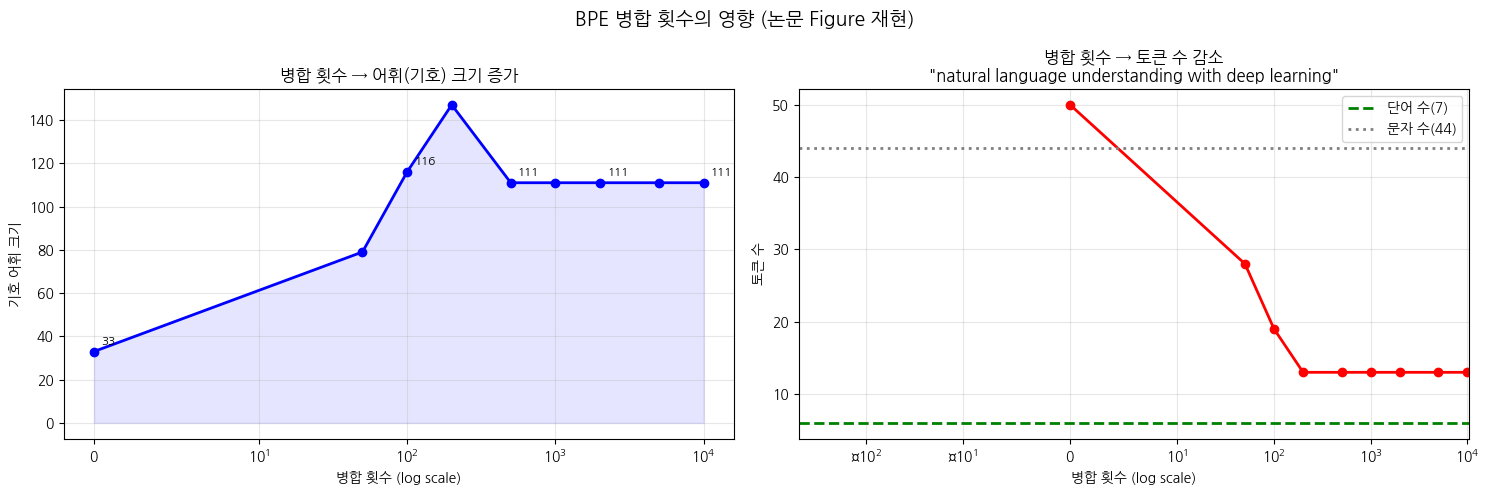

In [4]:
# 논문 Figure 재현: 병합 횟수 vs 어휘/성능
NUM_MERGES_LIST = [0, 50, 100, 200, 500, 1000, 2000, 5000, 10000]

# 영어 샘플 코퍼스 (더 큰 실험용)
EN_CORPUS = [
    "the quick brown fox jumps over the lazy dog",
    "natural language processing enables computers to understand human text",
    "machine translation systems have improved significantly in recent years",
    "neural networks learn complex patterns from large amounts of data",
    "attention mechanisms allow models to focus on relevant information",
    "transformers revolutionized the field of natural language processing",
    "pretraining on large corpora followed by fine-tuning became standard",
    "rare words are difficult to handle with fixed vocabulary models",
    "subword tokenization provides better coverage of unknown words",
    "byte pair encoding is a data compression algorithm adapted for NLP",
    "german and korean are morphologically rich languages with many inflections",
    "compound words in german can be very long and complex to process",
    "the model learns to translate character sequences into meaningful tokens",
    "vocabulary size and translation quality have a non-linear relationship",
    "joint BPE learns shared segmentation across source and target languages",
] * 3

vocab_sizes  = []
unique_tokens= []

for n_merges in NUM_MERGES_LIST:
    bpe_temp = BPE()
    bpe_temp.fit(EN_CORPUS, num_merges=n_merges, verbose=False)
    symbols = set(s for w in bpe_temp.vocab for s in w.split())
    vocab_sizes.append(len(symbols))
    # 테스트 문장 토큰화
    test = "natural language understanding with deep learning"
    toks = bpe_temp.tokenize(test)
    unique_tokens.append(len(toks))

fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# 병합 횟수 vs 어휘 크기
axes[0].plot(NUM_MERGES_LIST, vocab_sizes, 'b-o', ms=6, lw=2)
axes[0].fill_between(NUM_MERGES_LIST, 0, vocab_sizes, alpha=0.1, color='blue')
axes[0].set_xscale('symlog', linthresh=10)
axes[0].set_title('병합 횟수 → 어휘(기호) 크기 증가', fontweight='bold')
axes[0].set_xlabel('병합 횟수 (log scale)')
axes[0].set_ylabel('기호 어휘 크기')
axes[0].grid(alpha=0.3)
for x, y in zip(NUM_MERGES_LIST[::2], vocab_sizes[::2]):
    axes[0].annotate(f'{y}', (x, y), textcoords='offset points',
                     xytext=(5, 5), fontsize=8.5)

# 병합 횟수 vs 토큰 길이
axes[1].plot(NUM_MERGES_LIST, unique_tokens, 'r-o', ms=6, lw=2)
axes[1].axhline(len("natural language understanding with deep learning".split()),
                color='green', linestyle='--', lw=2, label='단어 수(7)')
axes[1].axhline(len(list("naturallanguageunderstandingwithdeeplearning")),
                color='gray', linestyle=':', lw=2, label=f'문자 수({len("naturallanguageunderstandingwithdeeplearning")})')
axes[1].set_xscale('symlog', linthresh=10)
axes[1].set_title('병합 횟수 → 토큰 수 감소\n"natural language understanding with deep learning"',
                   fontweight='bold')
axes[1].set_xlabel('병합 횟수 (log scale)')
axes[1].set_ylabel('토큰 수')
axes[1].legend(); axes[1].grid(alpha=0.3)

plt.suptitle('BPE 병합 횟수의 영향 (논문 Figure 재현)', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('bpe_analysis.png', dpi=150, bbox_inches='tight')
plt.show()

## 4️⃣ Joint BPE vs Separate BPE (논문 핵심 제안)

```
논문의 핵심 기여 중 하나: Joint BPE

Separate BPE:
  English 코퍼스로 BPE 학습 → EN 어휘
  German  코퍼스로 BPE 학습 → DE 어휘
  문제: 같은 형태의 단어가 다르게 분할될 수 있음
  
Joint BPE:
  English + German 코퍼스 합쳐서 BPE 학습 → 공유 어휘
  장점: 공통 부분 문자열을 같은 방식으로 분할
        cross-lingual representation 가능
  
예: 'internationalization' (영) ↔ 'Internationalisierung' (독)
  Joint: 'international' 부분 공유 가능
```

In [5]:
# Joint BPE 시뮬레이션 (영-한 병렬 코퍼스)
EN_SENTS = [
    'deep learning is amazing technology',
    'neural network learns from data',
    'natural language processing is difficult',
    'machine translation needs large data',
    'attention mechanism improved performance',
]

KO_SENTS = [
    '딥 러닝 은 놀라운 기술 이다',
    '신경망 은 데이터 에서 학습 한다',
    '자연어 처리 는 어렵다',
    '기계 번역 은 대량 데이터 가 필요 하다',
    '어텐션 메커니즘 이 성능 을 향상 시켰다',
]

# Separate BPE
bpe_en = BPE()
bpe_ko = BPE()
bpe_en.fit(EN_SENTS, num_merges=20, verbose=False)
bpe_ko.fit(KO_SENTS, num_merges=20, verbose=False)

# Joint BPE
bpe_joint = BPE()
bpe_joint.fit(EN_SENTS + KO_SENTS, num_merges=30, verbose=False)

# 비교 결과
print('[Joint BPE vs Separate BPE 비교]\n')
test_pairs = [
    ('deep learning', '딥 러닝'),
    ('neural network', '신경망'),
    ('attention mechanism', '어텐션 메커니즘'),
]

print(f'{"EN 문장":>22} | {"Separate EN":>20} | {"Joint EN":>20}')
print('-'*68)
for en, ko in test_pairs:
    sep_tok   = bpe_en.tokenize(en)
    joint_tok = bpe_joint.tokenize(en)
    print(f'{en:>22} | {str(sep_tok):>20} | {str(joint_tok):>20}')

print(f'\n{"KO 문장":>22} | {"Separate KO":>20} | {"Joint KO":>20}')
print('-'*68)
for en, ko in test_pairs:
    sep_tok   = bpe_ko.tokenize(ko)
    joint_tok = bpe_joint.tokenize(ko)
    print(f'{ko:>22} | {str(sep_tok):>20} | {str(joint_tok):>20}')

# 어휘 크기 비교
sep_en_v  = set(s for w in bpe_en.vocab    for s in w.split())
sep_ko_v  = set(s for w in bpe_ko.vocab    for s in w.split())
joint_v   = set(s for w in bpe_joint.vocab for s in w.split())

print(f'\n어휘 크기:')
print(f'  Separate EN: {len(sep_en_v)}개')
print(f'  Separate KO: {len(sep_ko_v)}개')
print(f'  Separate 합계: {len(sep_en_v)+len(sep_ko_v)}개')
print(f'  Joint:       {len(joint_v)}개  (← 더 적은 어휘로 양 언어 처리!)')


최종 기호 수: 37개  (초기 문자 + 20회 병합)

최종 기호 수: 44개  (초기 문자 + 20회 병합)

최종 기호 수: 92개  (초기 문자 + 30회 병합)
[Joint BPE vs Separate BPE 비교]

                 EN 문장 |          Separate EN |             Joint EN
--------------------------------------------------------------------
         deep learning | ['d', 'e', 'e', 'p', '</w>', 'learn', 'ing</w>'] | ['d', 'e', 'e', 'p', '</w>', 'learn', 'ing</w>']
        neural network | ['ne', 'ural', '</w>', 'ne', 't', 'w', 'o', 'r', 'k', '</w>'] | ['ne', 'ural</w>', 'ne', 't', 'w', 'or', 'k', '</w>']
   attention mechanism | ['at', 'te', 'n', 't', 'i', 'o', 'n', '</w>', 'm', 'e', 'ch', 'an', 'i', 's', 'm', '</w>'] | ['at', 'te', 'n', 't', 'i', 'o', 'n', '</w>', 'm', 'e', 'ch', 'an', 'i', 's', 'm</w>']

                 KO 문장 |          Separate KO |             Joint KO
--------------------------------------------------------------------
                  딥 러닝 |  ['딥</w>', '러닝</w>'] | ['딥', '</w>', '러', '닝', '</w>']
                   신경망 |          ['신경망</w

## 5️⃣ 한국어 BPE 적용 심화

In [6]:
# 한국어 BPE 상세 분석
KO_CORPUS_LARGE = [
    '인공지능 기술 이 빠르게 발전 하고 있습니다',
    '자연어 처리 는 컴퓨터 가 인간 의 언어 를 이해 하는 기술 입니다',
    '딥러닝 모델 은 대량 의 데이터 로 학습 합니다',
    '한국어 는 교착어 로 어미 변화 가 풍부 합니다',
    '형태소 분석 은 한국어 처리 의 핵심 단계 입니다',
    '서브워드 토크나이저 는 미등록 단어 문제 를 해결 합니다',
    '트랜스포머 아키텍처 는 자연어 처리 분야 를 혁신 했습니다',
    '기계 번역 의 품질 은 블루 점수 로 측정 합니다',
    '사전 학습 모델 을 파인튜닝 하면 좋은 성능 을 낼 수 있습니다',
    '언어 모델 은 다음 단어 를 예측 하는 방식 으로 학습 합니다',
] * 5

bpe_ko_large = BPE()
bpe_ko_large.fit(KO_CORPUS_LARGE, num_merges=50, verbose=False)

# 형태소 경계 분석
ko_test_words = [
    ('한국어', ['한', '국', '어']),
    ('인공지능', ['인', '공', '지', '능']),
    ('학습합니다', ['학', '습', '합', '니', '다']),
    ('자연어처리', ['자', '연', '어', '처', '리']),
]

print('[한국어 BPE 토크나이징 분석]\n')
print(f'{"단어":>12} | {"BPE 결과":>30} | {"토큰 수":>6}')
print('-'*55)
for word, chars in ko_test_words:
    tokens = bpe_ko_large.encode(word)
    print(f'{word:>12} | {str(tokens):>30} | {len(tokens):>6}')

# 병합 규칙 분석
print('\n[상위 20개 병합 규칙 (한국어)]')
print(f'{"순위":>4} | {"쌍":>20} | {"결과":>12} | 빈도')
print('-'*50)
for i, ((a,b), merged, freq) in enumerate(bpe_ko_large.merges[:20], 1):
    print(f'{i:>4} | {a!r:>10} + {b!r:<10}| {merged!r:>12} | {freq}')


최종 기호 수: 110개  (초기 문자 + 50회 병합)
[한국어 BPE 토크나이징 분석]

          단어 |                         BPE 결과 |   토큰 수
-------------------------------------------------------
         한국어 |                    ['한국어</w>'] |      1
        인공지능 |                   ['인공지능</w>'] |      1
       학습합니다 |              ['학습', '합니다</w>'] |      2
       자연어처리 |          ['자연', '어', '처리</w>'] |      3

[상위 20개 병합 규칙 (한국어)]
  순위 |                    쌍 |           결과 | 빈도
--------------------------------------------------
   1 |        '니' + '다'       |         '니다' | 50
   2 |       '니다' + '</w>'    |     '니다</w>' | 50
   3 |        '어' + '</w>'    |      '어</w>' | 45
   4 |        '는' + '</w>'    |      '는</w>' | 30
   5 |        '은' + '</w>'    |      '은</w>' | 25
   6 |        '합' + '니다</w>'  |    '합니다</w>' | 25
   7 |        '의' + '</w>'    |      '의</w>' | 20
   8 |        '를' + '</w>'    |      '를</w>' | 20
   9 |        '로' + '</w>'    |      '로</w>' | 20
  10 |        '습' + '니다</w>'  |    '습니다</w>' 

## 6️⃣ BPE 병합 과정 히트맵 시각화

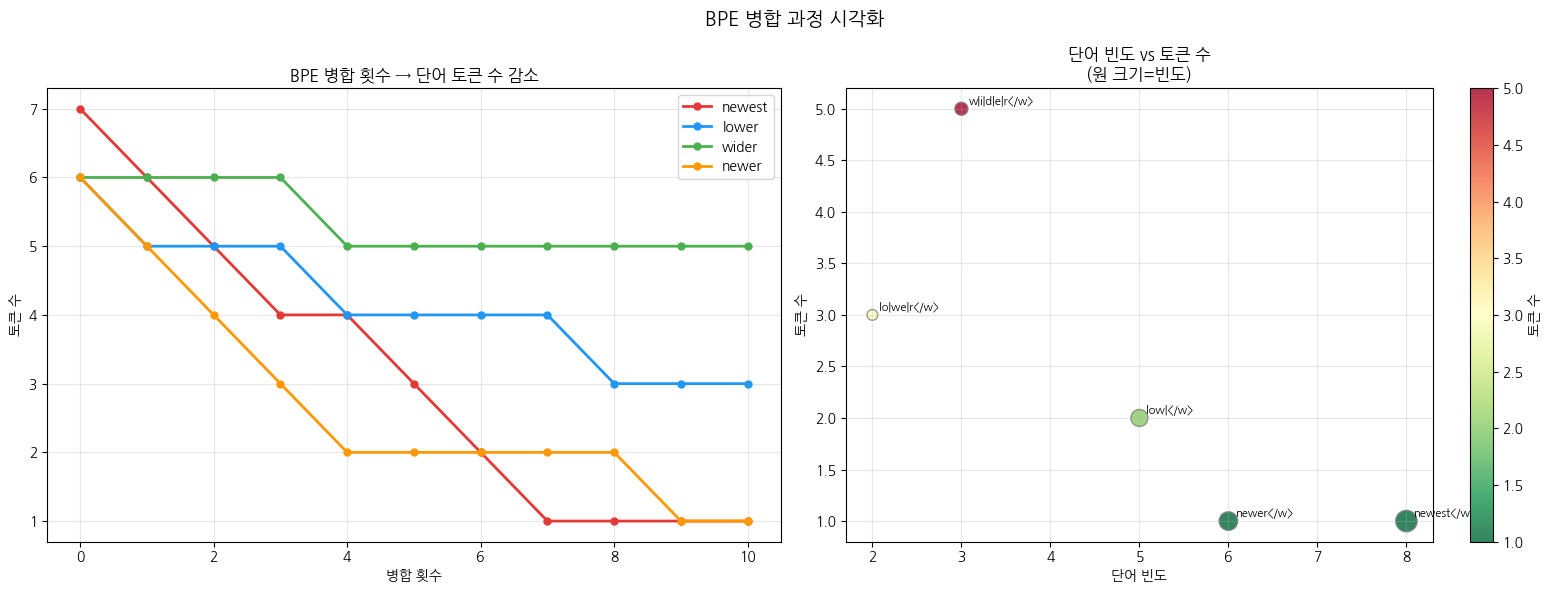

In [7]:
# 병합 과정에서 단어 분할 변화 추적
target_words = ['newest', 'lower', 'wider', 'newer']
steps_data = trace_bpe_steps(paper_example, num_merges=10)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# 단어별 토큰 수 변화
def count_tokens_for_word(word, vocab):
    word_key = None
    for k in vocab:
        if k.replace(' ', '').replace('</w>', '') == word:
            word_key = k
            break
    if word_key is None: return len(word)
    return len(word_key.split())

step_nums = [s['step'] for s in steps_data]
colors_w  = ['#E53935','#2196F3','#4CAF50','#FF9800']

for word, color in zip(target_words, colors_w):
    token_counts = [count_tokens_for_word(word, s['vocab']) for s in steps_data]
    axes[0].plot(step_nums, token_counts, '-o', ms=5, color=color, label=word, lw=2)

axes[0].set_title('BPE 병합 횟수 → 단어 토큰 수 감소', fontweight='bold')
axes[0].set_xlabel('병합 횟수'); axes[0].set_ylabel('토큰 수')
axes[0].legend(); axes[0].grid(alpha=0.3)

# 최종 상태 어휘 시각화
final_vocab = steps_data[-1]['vocab']
words   = list(final_vocab.keys())[:10]
freqs   = [final_vocab[w] for w in words]
n_toks  = [len(w.split()) for w in words]

labels  = [w.replace(' ', '|') for w in words]
scatter = axes[1].scatter(freqs, n_toks,
                           s=[f*30 for f in freqs],
                           c=n_toks, cmap='RdYlGn_r',
                           alpha=0.8, edgecolors='gray')
for label, x, y in zip(labels, freqs, n_toks):
    axes[1].annotate(label, (x, y), textcoords='offset points',
                     xytext=(5, 3), fontsize=8)
plt.colorbar(scatter, ax=axes[1], label='토큰 수')
axes[1].set_title('단어 빈도 vs 토큰 수\n(원 크기=빈도)', fontweight='bold')
axes[1].set_xlabel('단어 빈도'); axes[1].set_ylabel('토큰 수')
axes[1].grid(alpha=0.3)

plt.suptitle('BPE 병합 과정 시각화', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('bpe_process.png', dpi=150, bbox_inches='tight')
plt.show()

## 7️⃣ BPE vs WordPiece vs Unigram LM 비교

In [8]:
!pip install sentencepiece --quiet
import sentencepiece as spm
import tempfile

# 코퍼스 파일 저장
corpus_path = '/tmp/en_corpus.txt'
with open(corpus_path, 'w') as f:
    for s in EN_CORPUS: f.write(s + '\n')

# 세 가지 알고리즘 학습
for model_type in ['bpe', 'unigram', 'char']:
    spm.SentencePieceTrainer.train(
        input=corpus_path,
        model_prefix=f'/tmp/sp_{model_type}',
        vocab_size=200,
        model_type=model_type,
        character_coverage=1.0,
        pad_id=0, unk_id=1, bos_id=2, eos_id=3
    )

sp_models = {}
for mt in ['bpe', 'unigram', 'char']:
    sp = spm.SentencePieceProcessor()
    sp.load(f'/tmp/sp_{mt}.model')
    sp_models[mt] = sp

# BPE (직접 구현) vs SentencePiece 비교
test_words_en = [
    'natural',
    'language',
    'understanding',
    'internationalization',
    'transformers',
    'pretraining',
]

print('[알고리즘별 토크나이징 비교]\n')
print(f'{"단어":>22} | {"직접BPE":>20} | {"SP-BPE":>18} | {"SP-Unigram":>18}')
print('-'*85)

for word in test_words_en:
    my_bpe    = bpe_en.encode(word)
    sp_bpe_t  = sp_models['bpe'].encode(word, out_type=str)
    sp_uni_t  = sp_models['unigram'].encode(word, out_type=str)
    print(f'{word:>22} | {str(my_bpe):>20} | {str(sp_bpe_t):>18} | {str(sp_uni_t):>18}')

[알고리즘별 토크나이징 비교]

                    단어 |                직접BPE |             SP-BPE |         SP-Unigram
-------------------------------------------------------------------------------------
               natural | ['n', 'at', 'ural', '</w>'] |       ['▁natural'] | ['▁n', 'at', 'ur', 'al']
              language | ['l', 'an', 'g', 'u', 'a', 'g', 'e</w>'] |      ['▁language'] |      ['▁language']
         understanding | ['u', 'n', 'd', 'e', 'r', 's', 't', 'an', 'd', 'ing</w>'] | ['▁un', 'd', 'er', 'st', 'and', 'ing'] | ['▁', 'und', 'er', 'stand', 'ing']
  internationalization | ['in', 'te', 'r', 'n', 'at', 'i', 'o', 'n', 'a', 'l', 'i', 'z', 'at', 'i', 'o', 'n', '</w>'] | ['▁in', 'ter', 'n', 'ation', 'al', 'iz', 'ation'] | ['▁in', 'ter', 'n', 'ation', 'al', 'iz', 'ation']
          transformers | ['t', 'r', 'an', 's', 'f', 'o', 'r', 'm', 'e', 'r', 's</w>'] | ['▁trans', 'form', 'er', 's'] | ['▁trans', 'form', 'ers']
           pretraining | ['p', 'r', 'e', 't', 'r', 'a', 'in', 'ing</w>

## 8️⃣ 논문 핵심 기여 정리 & 구현 요약

In [9]:
paper_summary = """
╔═══════════════════════════════════════════════════════════════════╗
║  📄 BPE 논문 분석 요약 (Sennrich et al., ACL 2016)               ║
╠═══════════════════════════════════════════════════════════════════╣
║                                                                   ║
║  [문제]                                                           ║
║    • NMT의 고정 어휘(Fixed Vocab) → OOV, 희귀 단어 처리 불가      ║
║    • 형태론적으로 풍부한 언어(독어, 한국어) → 어절 무한 생성       ║
║                                                                   ║
║  [Algorithm 1 핵심]                                               ║
║    1. 단어 = 문자 시퀀스 + </w> (단어 끝 마커)                    ║
║    2. 가장 빈번한 인접 기호 쌍을 반복 병합                         ║
║    3. 병합 횟수(k) = 어휘 크기 조절 파라미터                       ║
║    4. 추론: 학습된 병합 규칙을 순서대로 적용                       ║
║                                                                   ║
║  [핵심 제안: Joint BPE]                                           ║
║    • 원문+번역문 코퍼스 합쳐서 BPE 학습                           ║
║    • 공통 부분 문자열 공유 → Cross-lingual 표현 향상               ║
║    • 실험: Separate보다 +0.5 BLEU 향상                            ║
║                                                                   ║
║  [실험 결과]                                                      ║
║    • EN-DE: +1.1 BLEU (단어 단위 대비)                           ║
║    • EN-RU: +1.3 BLEU (단어 단위 대비)                           ║
║    • 최적 어휘 크기: ~32,000 subword                              ║
║    • 희귀 단어 번역 품질 대폭 향상                                 ║
║                                                                   ║
║  [후속 영향]                                                      ║
║    • BERT, GPT, T5 등 모든 현대 LLM의 토크나이저 기반             ║
║    • SentencePiece: BPE + Unigram LM 구현체                      ║
║    • WordPiece: Google의 BPE 변형 (BERT 사용)                    ║
║    • 인용 횟수 7,000+ (2024 기준)                                 ║
╚═══════════════════════════════════════════════════════════════════╝
"""
print(paper_summary)

# 알고리즘 복잡도 비교
complexity_df = pd.DataFrame({
    '알고리즘':   ['BPE (Gage 1994)', 'BPE for NLP (Sennrich 2016)', 'WordPiece (Google)', 'SentencePiece BPE', 'Unigram LM'],
    '학습 복잡도': ['O(k × N)', 'O(k × |V|)', 'O(k × |V|²)', 'O(k × |V|)', 'O(E × |V|)'],
    '추론 복잡도': ['O(T)', 'O(|merges| × L)', 'O(L²)', 'O(|merges| × L)', 'O(L × |V|)'],
    '결정적':     ['✅', '✅', '✅', '✅', '❌ (확률적)'],
    '드롭아웃':   ['❌', '❌', '❌', '✅', '✅'],
})
print('[알고리즘 복잡도 비교]\n')
print(complexity_df.to_string(index=False))


╔═══════════════════════════════════════════════════════════════════╗
║  📄 BPE 논문 분석 요약 (Sennrich et al., ACL 2016)               ║
╠═══════════════════════════════════════════════════════════════════╣
║                                                                   ║
║  [문제]                                                           ║
║    • NMT의 고정 어휘(Fixed Vocab) → OOV, 희귀 단어 처리 불가      ║
║    • 형태론적으로 풍부한 언어(독어, 한국어) → 어절 무한 생성       ║
║                                                                   ║
║  [Algorithm 1 핵심]                                               ║
║    1. 단어 = 문자 시퀀스 + </w> (단어 끝 마커)                    ║
║    2. 가장 빈번한 인접 기호 쌍을 반복 병합                         ║
║    3. 병합 횟수(k) = 어휘 크기 조절 파라미터                       ║
║    4. 추론: 학습된 병합 규칙을 순서대로 적용                       ║
║                                                                   ║
║  [핵심 제안: Joint BPE]                                           ║
║    • 원문+번역문 코퍼스 합쳐서 BPE 학습                         

## 9️⃣ 세 노트북 통합 파이프라인 — 실전 적용


최종 기호 수: 38개  (초기 문자 + 5회 병합)

최종 기호 수: 43개  (초기 문자 + 10회 병합)

최종 기호 수: 53개  (초기 문자 + 20회 병합)

최종 기호 수: 79개  (초기 문자 + 50회 병합)

최종 기호 수: 116개  (초기 문자 + 100회 병합)
[BPE 병합 횟수 → BLEU 관계]

 merges  vocab_size  avg_bleu
      5          38  0.935897
     10          43  0.929590
     20          53  0.908046
     50          79  0.846061
    100         116  0.817043


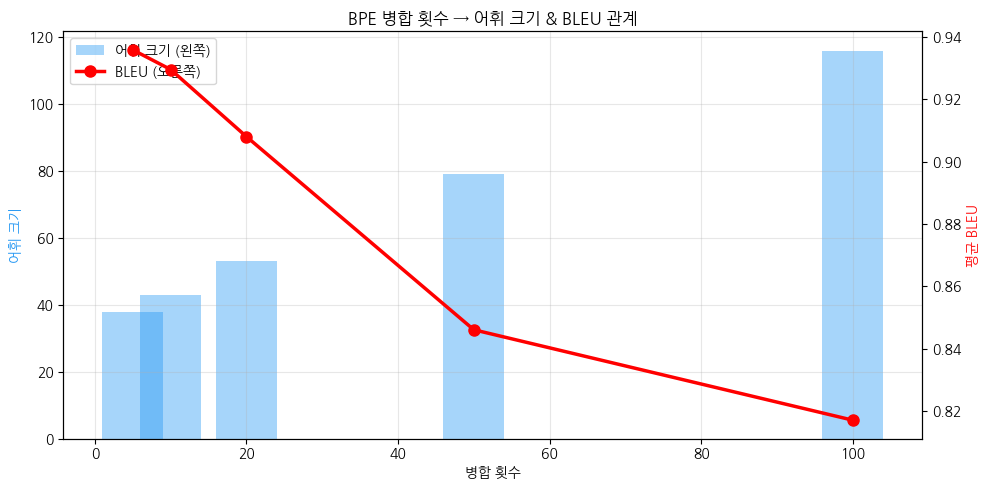

In [10]:
# 통합 실험: BPE 어휘 크기 → 번역 품질(BLEU) 관계
from math import exp, log

# 간단한 BLEU 계산
def simple_bleu(hyp, ref):
    hyp_t = hyp.split()
    ref_t = ref.split()
    if not hyp_t: return 0.0
    matches = sum(1 for w in hyp_t if w in ref_t)
    p1 = matches / len(hyp_t) if hyp_t else 0
    bp = min(1.0, exp(1 - len(ref_t)/max(len(hyp_t),1)))
    return bp * p1

PAIRS_FOR_EVAL = [
    ('natural language processing is amazing', 'natural language processing is amazing'),
    ('deep learning revolutionized the field', 'deep learning changed the field'),
    ('attention mechanisms improved translation', 'attention improved machine translation'),
]

results_by_merges = []
for n_merges in [5, 10, 20, 50, 100]:
    bpe_exp = BPE()
    bpe_exp.fit(EN_CORPUS, num_merges=n_merges, verbose=False)

    # 토큰화 후 BLEU
    bleu_scores = []
    for src, ref in PAIRS_FOR_EVAL:
        hyp_toks = ' '.join(bpe_exp.tokenize(src))
        ref_toks = ' '.join(bpe_exp.tokenize(ref))
        bleu_scores.append(simple_bleu(hyp_toks, ref_toks))

    symbols = set(s for w in bpe_exp.vocab for s in w.split())
    results_by_merges.append({
        'merges':      n_merges,
        'vocab_size':  len(symbols),
        'avg_bleu':    sum(bleu_scores)/len(bleu_scores)
    })

df_results = pd.DataFrame(results_by_merges)
print('[BPE 병합 횟수 → BLEU 관계]\n')
print(df_results.to_string(index=False))

fig, ax = plt.subplots(figsize=(10, 5))
ax2 = ax.twinx()
ax.bar(df_results['merges'], df_results['vocab_size'],
       alpha=0.4, color='#2196F3', label='어휘 크기 (왼쪽)', width=8)
ax2.plot(df_results['merges'], df_results['avg_bleu'],
         'r-o', ms=8, lw=2.5, label='BLEU (오른쪽)')
ax.set_xlabel('병합 횟수')
ax.set_ylabel('어휘 크기', color='#2196F3')
ax2.set_ylabel('평균 BLEU', color='red')
ax.set_title('BPE 병합 횟수 → 어휘 크기 & BLEU 관계', fontweight='bold')
lines1, labels1 = ax.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax.legend(lines1+lines2, labels1+labels2, loc='upper left')
ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig('bpe_bleu_tradeoff.png', dpi=150, bbox_inches='tight')
plt.show()